In [44]:
import pdfplumber
print(pdfplumber.__version__)

0.11.9


In [45]:
pdf = pdfplumber.open("example sources/Effeccts of Statins - Lancet (1).pdf")

In [46]:
p2 = pdf.pages[2]

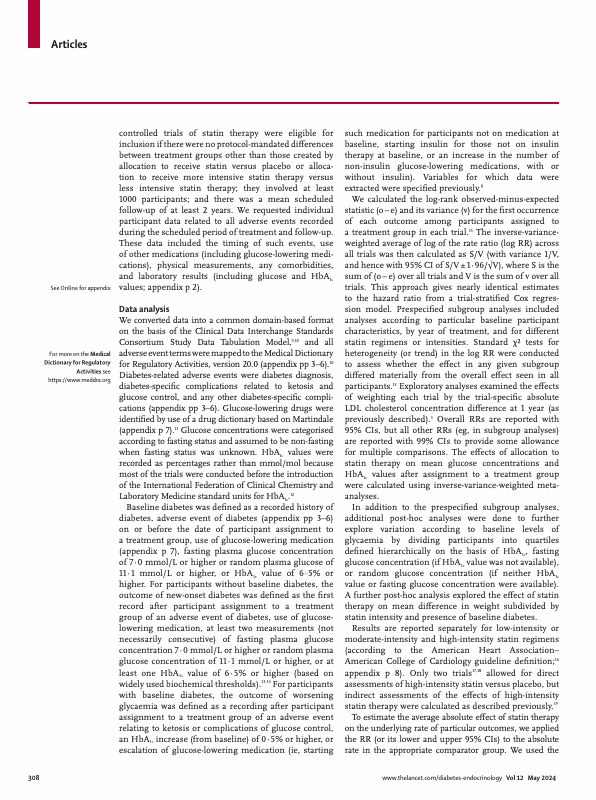

In [47]:
im = p2.to_image()
im

In [48]:
table = p2.extract_table()

In [49]:
table

## Extract tables from all pages

Loop through every page of the PDF, extract tables, and display each page image alongside its extracted data.

In [50]:
import pandas as pd
from IPython.display import display

def extract_tables_from_pdf(pdf_path, max_pages=None):
    """
    Extract tables from all pages of a PDF.
    
    Args:
        pdf_path: Path to the PDF file
        max_pages: Optional limit on number of pages to process
    
    Returns:
        dict: {page_num: {'tables': [...], 'dataframes': [...]}}
    """
    results = {}
    
    with pdfplumber.open(pdf_path) as pdf:
        total_pages = len(pdf.pages)
        pages_to_process = min(total_pages, max_pages) if max_pages else total_pages
        
        print(f"Processing {pages_to_process} of {total_pages} pages...\n")
        print("=" * 80)
        
        for page_num, page in enumerate(pdf.pages[:pages_to_process], start=1):
            print(f"\n PAGE {page_num}")
            print("-" * 40)
            
            # Display page image
            img = page.to_image(resolution=100)
            display(img)
            
            # Find all tables on this page
            tables = page.find_tables()
            
            if not tables:
                print("No tables found on this page.")
                results[page_num] = {'tables': [], 'dataframes': []}
                continue
            
            print(f"Found {len(tables)} table(s)")
            
            page_tables = []
            page_dfs = []
            
            for table_idx, table in enumerate(tables, start=1):
                print(f"\n  Table {table_idx} (bbox: {table.bbox})")
                
                # Extract table data
                table_data = table.extract()
                
                if table_data and len(table_data) > 0:
                    # Convert to DataFrame
                    if len(table_data) > 1:
                        df = pd.DataFrame(table_data[1:], columns=table_data[0])
                    else:
                        df = pd.DataFrame(table_data)
                    
                    print(f"  Rows: {len(df)}, Columns: {len(df.columns)}")
                    display(df)
                    
                    page_tables.append(table_data)
                    page_dfs.append(df)
                else:
                    print("  (Empty table)")
            
            results[page_num] = {
                'tables': page_tables,
                'dataframes': page_dfs
            }
            
            print("\n" + "=" * 80)
    
    return results

Processing 10 of 14 pages...


 PAGE 1
----------------------------------------


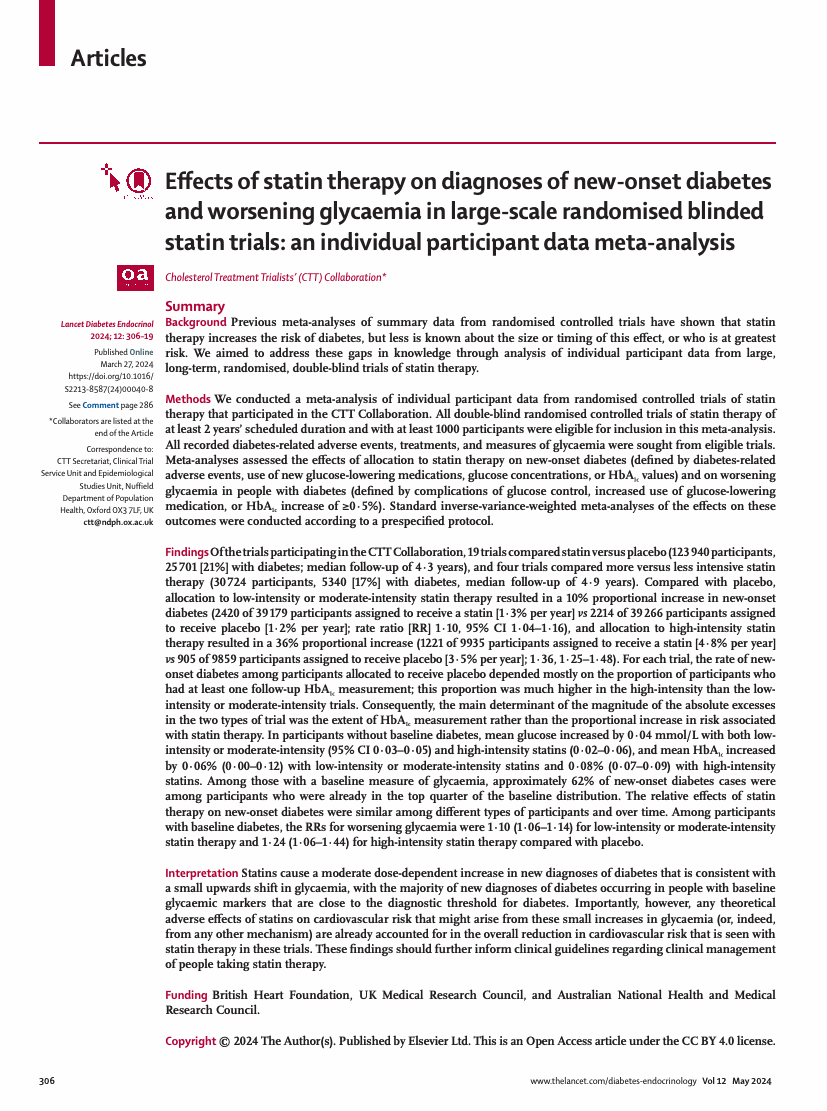

No tables found on this page.

 PAGE 2
----------------------------------------


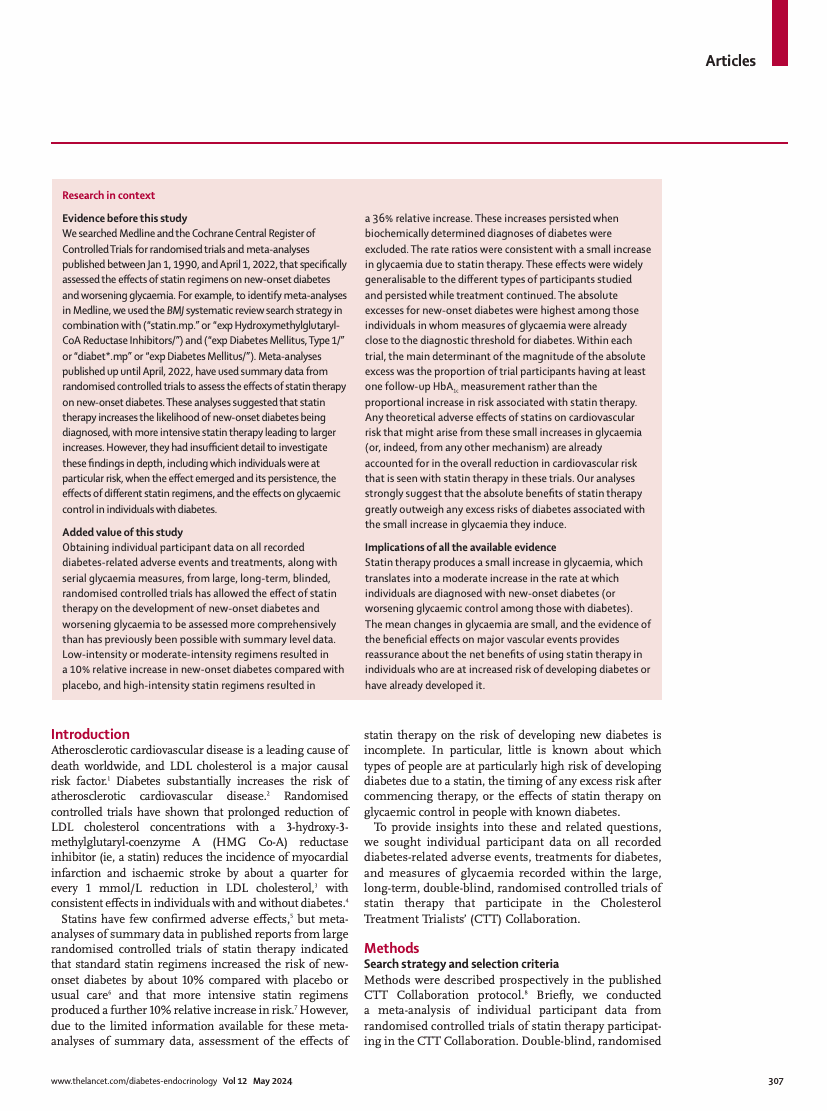

No tables found on this page.

 PAGE 3
----------------------------------------


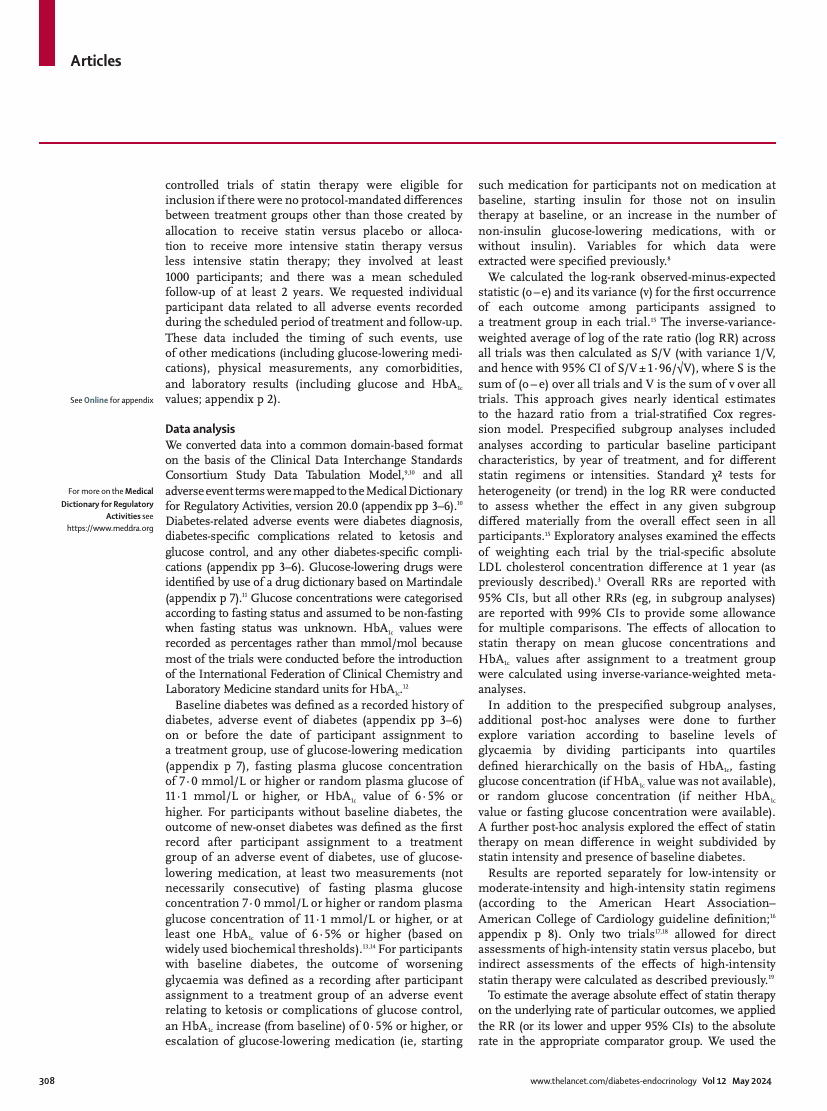

No tables found on this page.

 PAGE 4
----------------------------------------


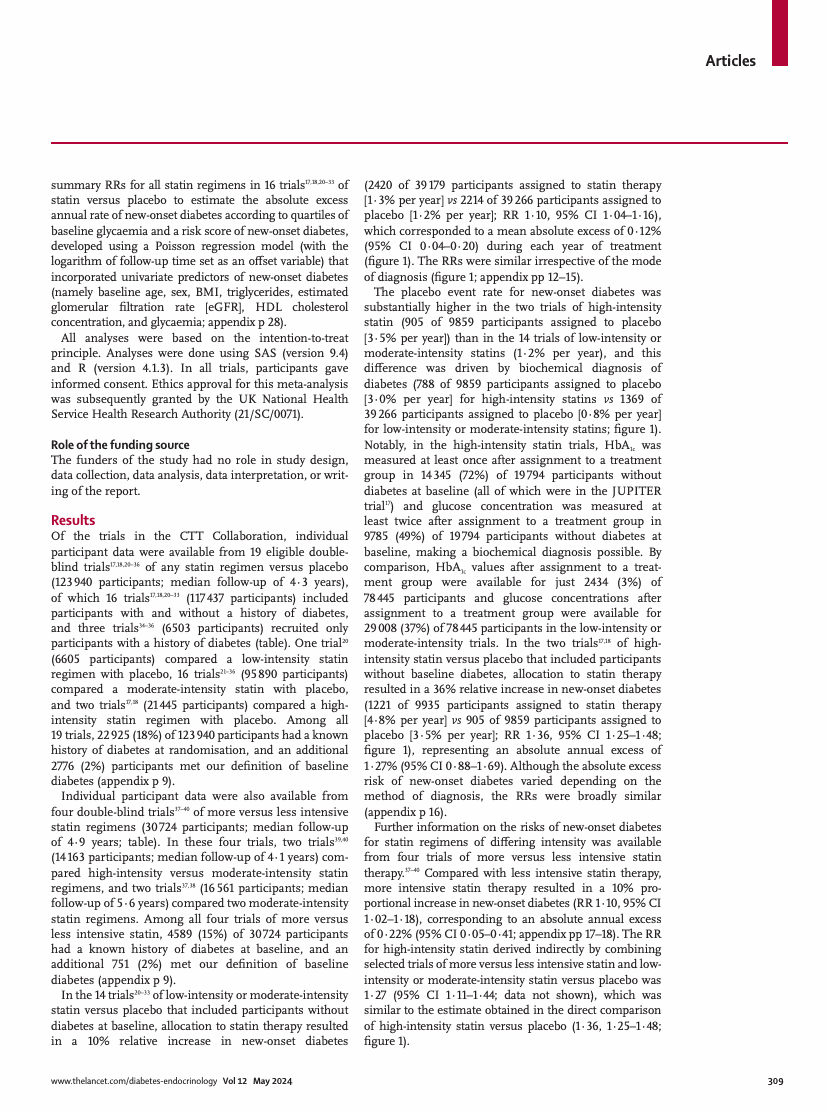

No tables found on this page.

 PAGE 5
----------------------------------------


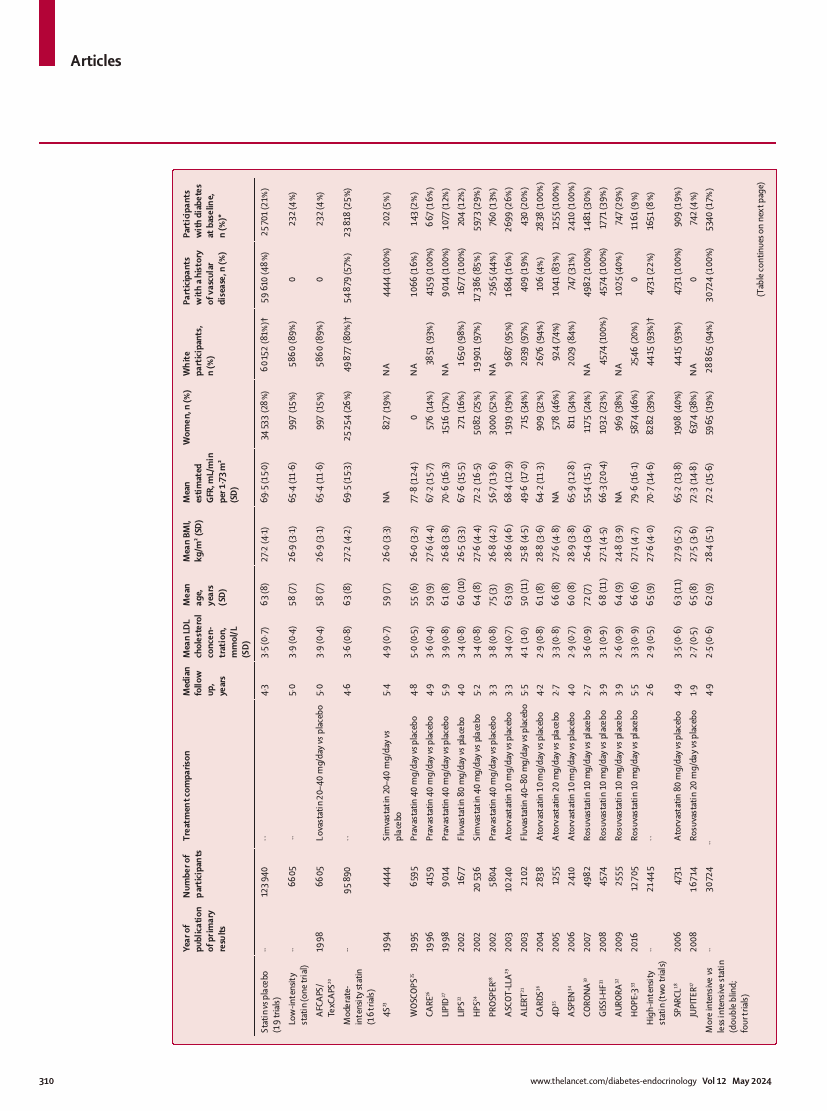

No tables found on this page.

 PAGE 6
----------------------------------------


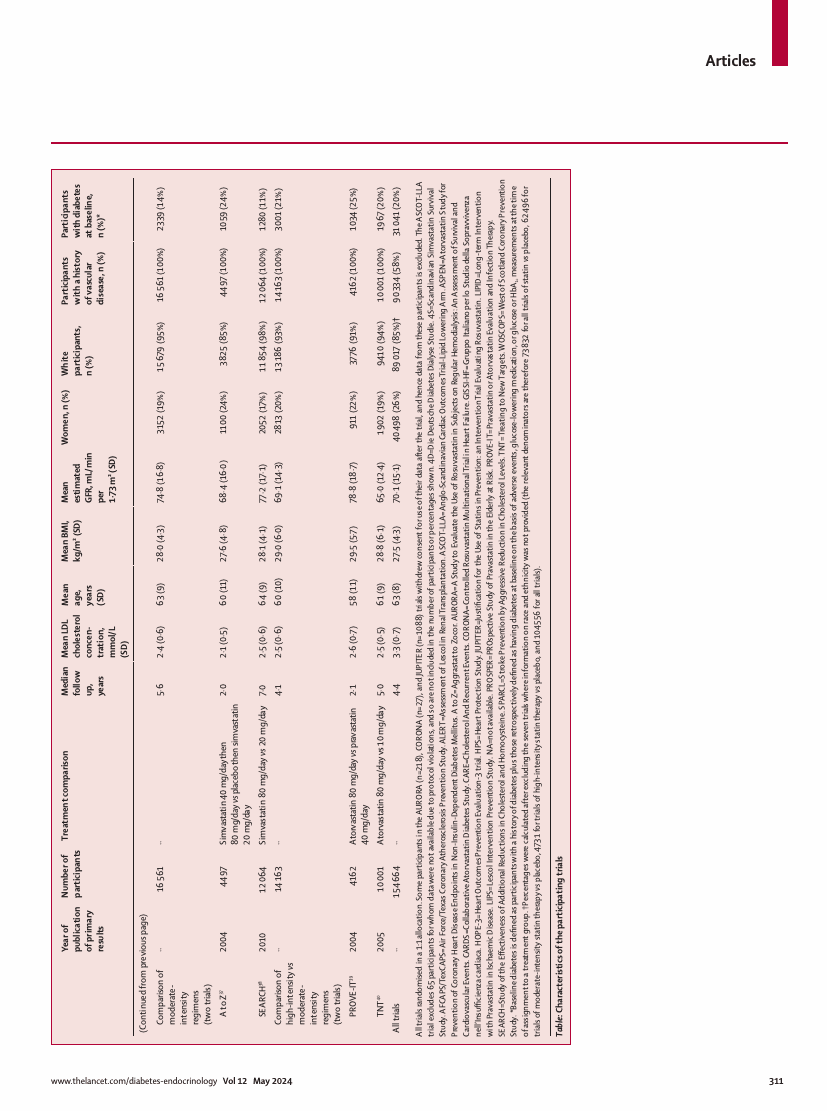

No tables found on this page.

 PAGE 7
----------------------------------------


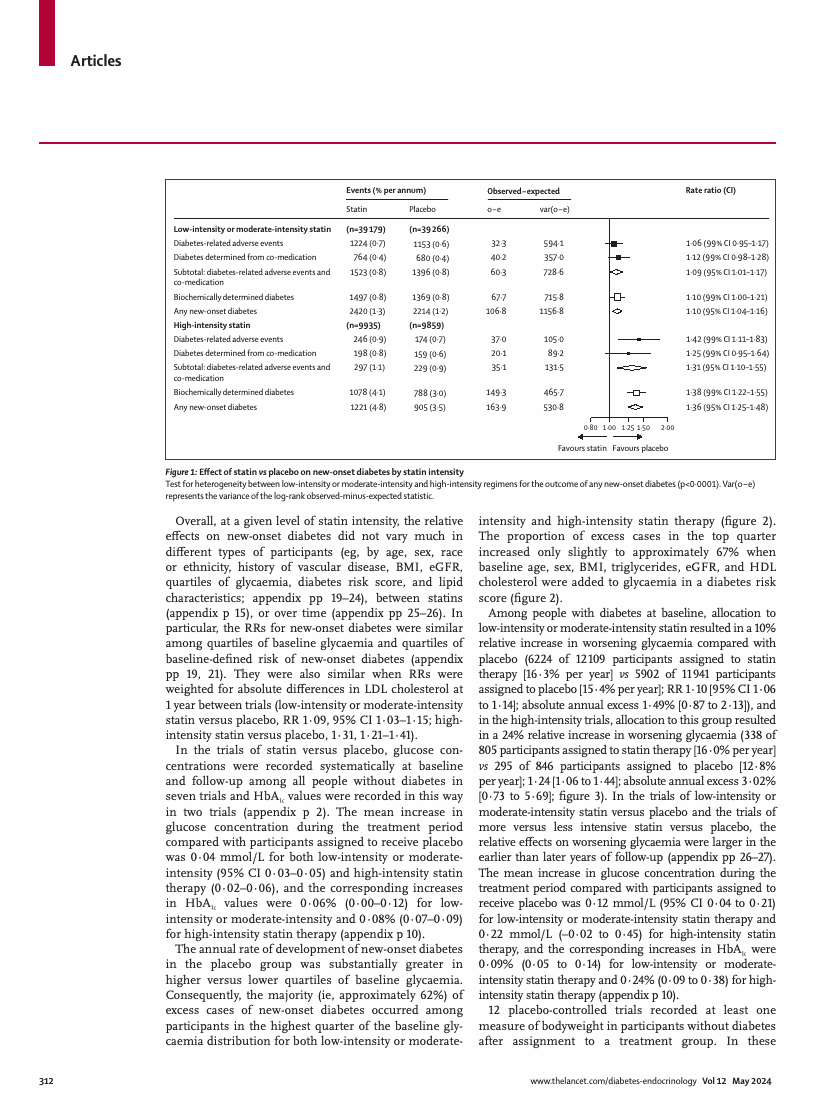

No tables found on this page.

 PAGE 8
----------------------------------------


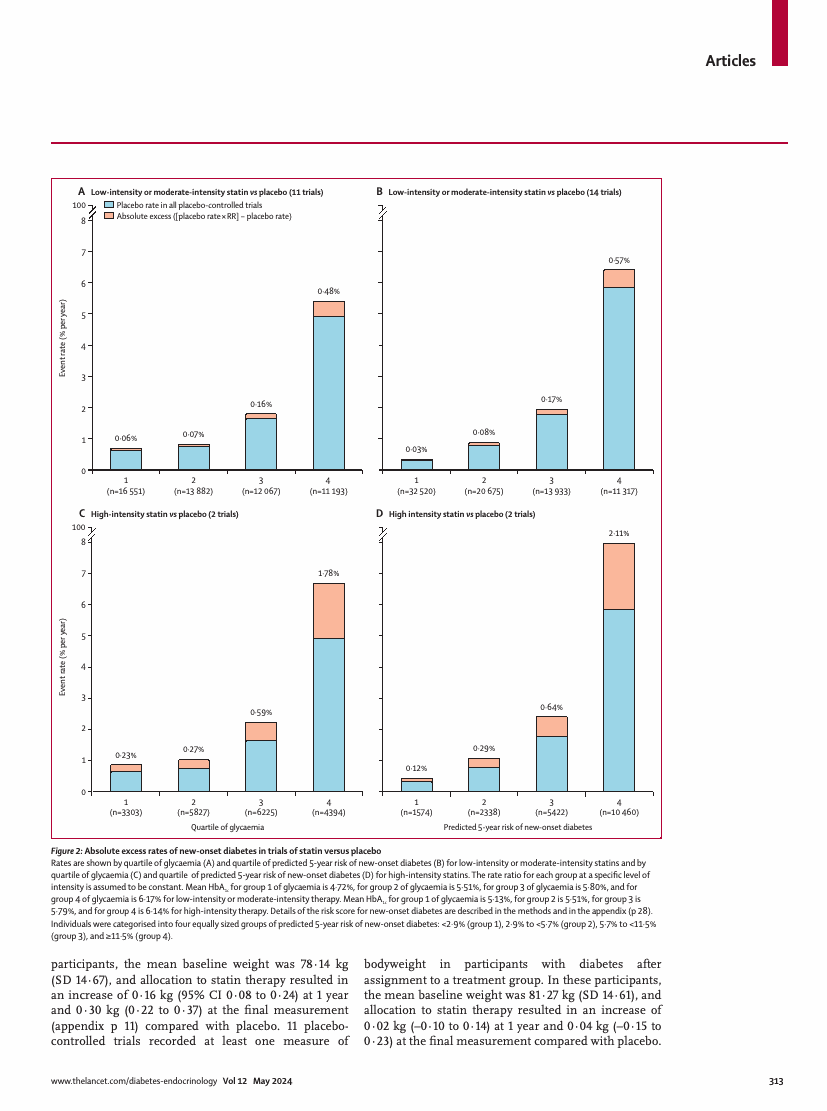

Found 8 table(s)

  Table 1 (bbox: (434.66200000000003, 194.18399999999997, 456.879, 338.17000103333334))
  Rows: 1, Columns: 1


,
0,



  Table 2 (bbox: (225.647, 217.10199999999998, 247.874, 338.17000103333334))
  Rows: 1, Columns: 1


,
0,



  Table 3 (bbox: (386.03499999999997, 293.66266866666666, 408.263, 338.17000103333334))
  Rows: 1, Columns: 1


...


  Table 7 (bbox: (386.03499999999997, 515.601, 408.263, 569.7939986666667))
  Rows: 1, Columns: 1


,
0,



  Table 8 (bbox: (176.99, 519.765, 199.208, 569.7939986666667))
  Rows: 1, Columns: 1


,
0,




 PAGE 9
----------------------------------------


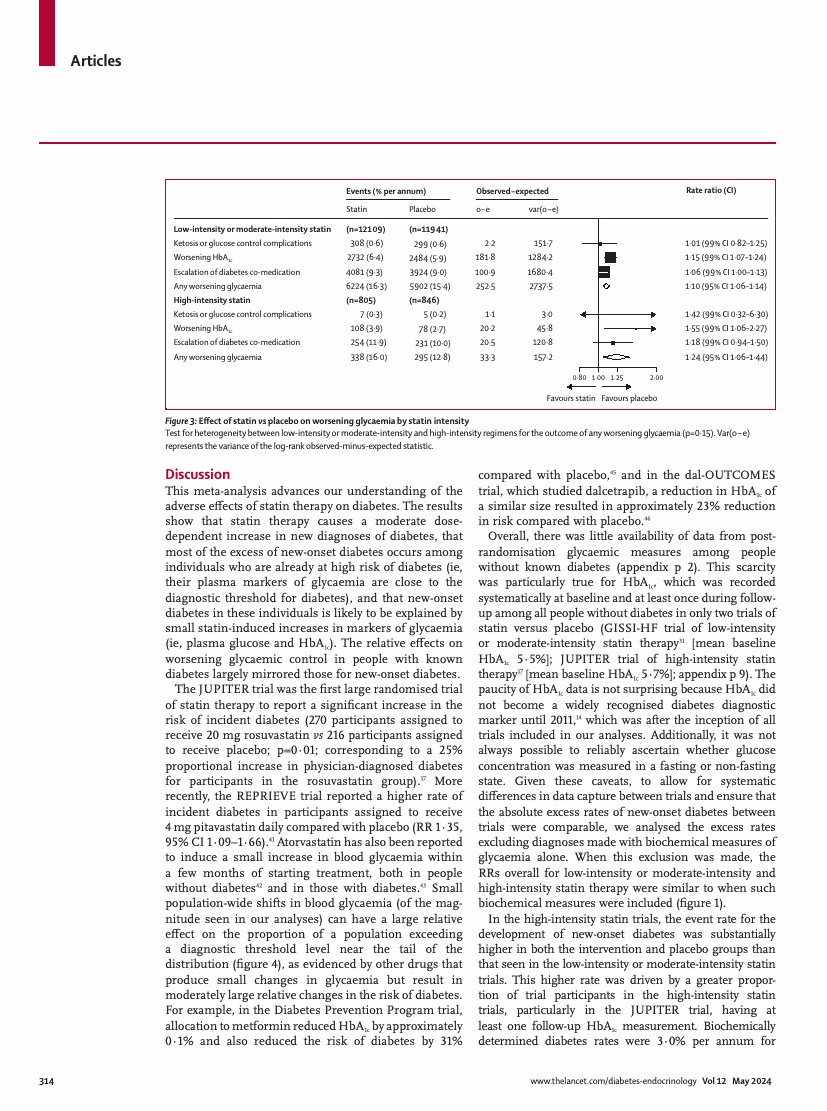

No tables found on this page.

 PAGE 10
----------------------------------------


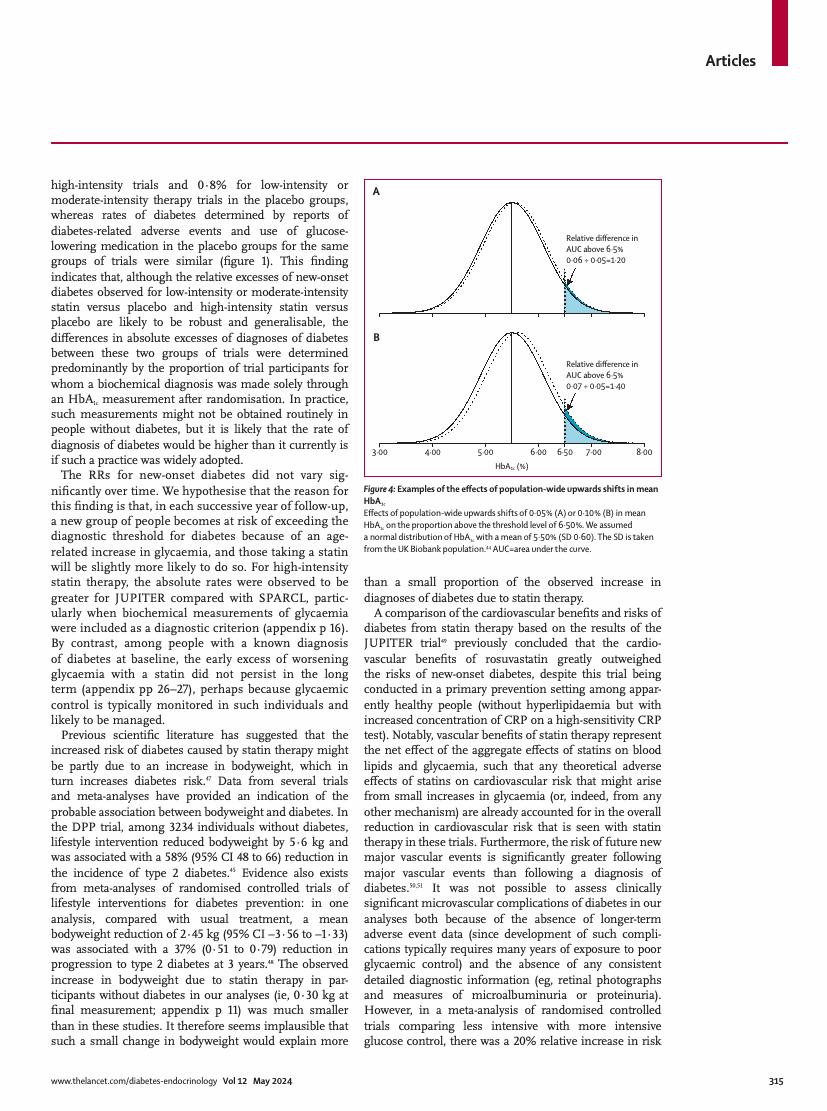

No tables found on this page.


In [51]:
# Extract tables from all pages (limit to first 10 pages for demo)
all_results = extract_tables_from_pdf("example sources/Effeccts of Statins - Lancet (1).pdf", max_pages=10)

In [52]:
# Summary of extraction results
print("EXTRACTION SUMMARY")
print("=" * 40)

total_tables = 0
total_rows = 0

for page_num, data in all_results.items():
    num_tables = len(data['tables'])
    num_rows = sum(len(df) for df in data['dataframes'])
    total_tables += num_tables
    total_rows += num_rows
    status = f"{num_tables} table(s), {num_rows} rows" if num_tables > 0 else "No tables"
    print(f"Page {page_num}: {status}")

print("-" * 40)
print(f"TOTAL: {total_tables} tables, {total_rows} data rows across {len(all_results)} pages")

EXTRACTION SUMMARY
Page 1: No tables
Page 2: No tables
Page 3: No tables
Page 4: No tables
Page 5: No tables
Page 6: No tables
Page 7: No tables
Page 8: 8 table(s), 8 rows
Page 9: No tables
Page 10: No tables
----------------------------------------
TOTAL: 8 tables, 8 data rows across 10 pages
